
# การสร้างแหล่งข้อมูลท้องถิ่น

สร้างและบันทึกชุดข้อมูลออฟไลน์เพื่อใช้ในไปป์ไลน์ inference

ตัวอย่างนี้สาธิตวิธีการ:

- สร้างชุดข้อมูลออฟไลน์ขนาดเล็กโดยการดึงข้อมูลและเขียนไปยังร้านค้า Zarr
- โหลดร้านค้าในพื้นที่เป็นแหล่งข้อมูลสำหรับไปป์ไลน์ inference ด้วยโมเดล Microsoft Aurora
- รัน deterministic workflow และพล็อตผลลัพธ์


In [1]:
# /// script
# dependencies = [
#   "earth2studio[aurora] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## การเตรียมองค์ประกอบ
สำหรับตัวอย่างนี้ จำเป็นต้องมีสิ่งต่อไปนี้:

- Prognostic Model: ใช้ Aurora รุ่น 6 ชั่วโมงในตัว :py:class:`earth2studio.models.px.Aurora`
- แหล่งข้อมูล: ดึงข้อมูลจากข้อมูล WeatherBench2 API :py:class:`earth2studio.data.WB2ERA5`



In [2]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()

from earth2studio.data import WB2ERA5, fetch_data
from earth2studio.models.px import Aurora

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลด checkpoint จาก GCP
package = Aurora.load_default_package()
model = Aurora.load_model(package)

# สร้างแหล่งข้อมูล แคชเป็นเท็จ
wb2 = WB2ERA5(cache=False, verbose=False)

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


## การสร้างร้านค้า Zarr ในพื้นที่จาก Datasource
เริ่มต้นด้วยการสร้างชุดข้อมูลในเครื่องจากที่เก็บข้อมูล WeatherBench2 ตั้งแต่ข้อมูล
แหล่งที่มาส่งคืนอาร์เรย์ข้อมูลในหน่วยความจำ ซึ่งสามารถทำได้หลายวิธี
ต่อไปนี้เป็นวิธีง่าย ๆ โดยใช้อ็อบเจ็กต์ Earth2Studio IO เพื่อแพ็คสิ่งที่ร้องขอ
ข้อมูลลงในที่เก็บ Zarr เดียว

สำหรับตัวอย่างนี้ มาดาวน์โหลดข้อมูลบางอย่างสำหรับ Microsoft aurora forecast



In [3]:
from collections import OrderedDict

import numpy as np

from earth2studio.io import ZarrBackend
from earth2studio.utils.coords import split_coords

times = np.array(
    [np.datetime64("2022-01-01T00:00:00"), np.datetime64("2022-01-01T06:00:00")]
)
variables = model.input_coords()["variable"]
zarr_path = "./outputs/19_wb2_dataset.zarr"
# สร้างที่เก็บ Zarr เพื่อแพ็คข้อมูลเข้าไป
zb = ZarrBackend(file_name=zarr_path, backend_kwargs={"overwrite": True})
full_coords = OrderedDict(
    [
        ("time", np.atleast_1d(times)),
        ("lead_time", np.array([np.timedelta64(0, "h")])),
        ("lat", np.linspace(90, -90, 721)),
        ("lon", np.linspace(0, 359.75, 1440)),
    ]
)
zb.add_array(full_coords, array_name=list(variables))

# วนซ้ำการประทับเวลา ดึงข้อมูล และเขียนส่วนต่างๆ ลงในอาร์เรย์ที่สร้างไว้ล่วงหน้า
for t in np.atleast_1d(times):
    x, coords = fetch_data(
        wb2,
        time=np.array([t]),
        variable=variables,
        lead_time=np.array([np.timedelta64(0, "h")]),
        device="cpu",
    )
    xs, reduced_coords, var_names = split_coords(x, coords, dim="variable")
    zb.write(xs, reduced_coords, array_name=list(var_names))

2026-04-26 21:07:03.591 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v200 at 2022-01-01T00:00:00
2026-04-26 21:07:03.591 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: z50 at 2022-01-01T00:00:00
2026-04-26 21:07:03.591 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: q200 at 2022-01-01T00:00:00
2026-04-26 21:07:03.591 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t400 at 2022-01-01T00:00:00
2026-04-26 21:07:03.591 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u700 at 2022-01-01T00:00:00
2026-04-26 21:07:03.591 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v1000 at 2022-01-01T00:00:00
2026-04-26 21:07:03.591 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v150 at 2022-01-01T00:00:00

โปรดทราบว่าร้านค้า Zarr ที่เราเพิ่งสร้างขึ้นสามารถใช้งานได้มากกว่า Earth2Studio
ไปป์ไลน์ inference เปิดด้วย zarr หรือ xarray เพื่อสำรวจ/ประมวลผลอะไร
คุณเพิ่งดาวน์โหลด



In [4]:
import zarr

zg = zarr.group(store=zarr.storage.LocalStore(zarr_path))
print(zg.tree())

/
├── lat (721,) float64
├── lead_time (1,) timedelta64[h]
├── lon (1440,) float64
├── msl (2, 1, 721, 1440) float32
├── q100 (2, 1, 721, 1440) float32
├── q1000 (2, 1, 721, 1440) float32
├── q150 (2, 1, 721, 1440) float32
├── q200 (2, 1, 721, 1440) float32
├── q250 (2, 1, 721, 1440) float32
├── q300 (2, 1, 721, 1440) float32
├── q400 (2, 1, 721, 1440) float32
├── q50 (2, 1, 721, 1440) float32
├── q500 (2, 1, 721, 1440) float32
├── q600 (2, 1, 721, 1440) float32
├── q700 (2, 1, 721, 1440) float32
├── q850 (2, 1, 721, 1440) float32
├── q925 (2, 1, 721, 1440) float32
├── t100 (2, 1, 721, 1440) float32
├── t1000 (2, 1, 721, 1440) float32
├── t150 (2, 1, 721, 1440) float32
├── t200 (2, 1, 721, 1440) float32
├── t250 (2, 1, 721, 1440) float32
├── t2m (2, 1, 721, 1440) float32
├── t300 (2, 1, 721, 1440) float32
├── t400 (2, 1, 721, 1440) float32
├── t50 (2, 1, 721, 1440) float32
├── t500 (2, 1, 721, 1440) float32
├── t600 (2, 1, 721, 1440) float32
├── t700 (2, 1, 721, 1440) float32
├── t850 

## การรัน Workflow
หากต้องการใช้ชุดข้อมูลที่บันทึกไว้เป็นแหล่งข้อมูล เราสามารถสร้างคลาสของเราเองที่นำไปใช้ได้
อินเทอร์เฟซที่ต้องการโดย :py:class:`earth2studio.data.base.Datasource` ซึ่งต้องการ
เพียงวิธี ``__call__(time, variable)``

อย่างไรก็ตาม เนื่องจากเราใช้ IO Backend จาก Earth2Studio เราจึงสามารถใช้
:py:class:`earth2studio.data.xr.InferenceOutputSource` ซึ่งเป็นระดับความสะดวกสบาย
ที่รองรับเอาต์พุตของไปป์ไลน์ inference



In [5]:
import earth2studio.run as run
from earth2studio.data import InferenceOutputSource

offline_source = InferenceOutputSource(zarr_path)
out_zarr_path = "./outputs/19_pangu_output.zarr"
io = ZarrBackend(file_name=out_zarr_path, backend_kwargs={"overwrite": True})
io = run.deterministic(
    times[-1:],
    4,
    model,
    offline_source,
    io,
    output_coords=OrderedDict({"variable": np.array(["msl"])}),
)

2026-04-26 21:08:38.933 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-26 21:08:38.933 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda
2026-04-26 21:08:39.696 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from InferenceOutputSource
2026-04-26 21:08:39.715 | INFO     | earth2studio.run:deterministic:139 - Inference starting!


Running inference: 100%|██████████| 5/5 [00:54<00:00, 10.96s/it]

2026-04-26 21:09:34.507 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


## การทำ Post-Processing
ขั้นตอนสุดท้ายคือ post-process ผลลัพธ์ของเรา



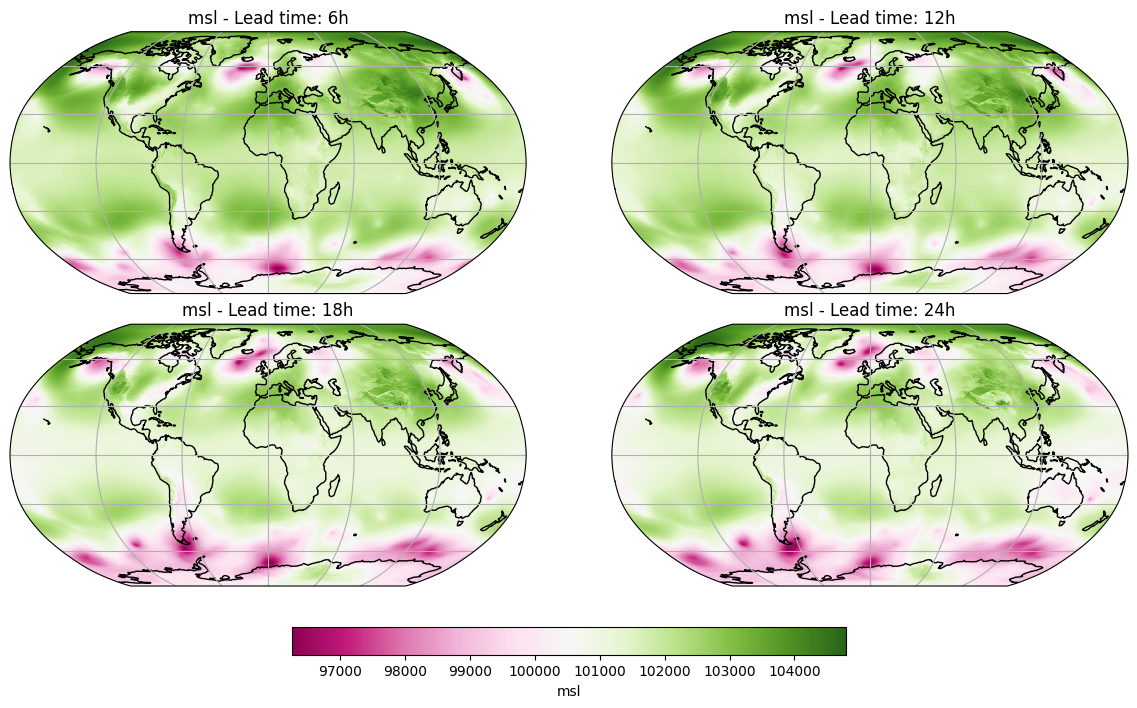

In [6]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

plt.close("all")
projection = ccrs.Robinson()
fig, axes = plt.subplots(
    2,
    2,
    subplot_kw={"projection": projection},
    figsize=(12, 7),
    constrained_layout=True,
)
axes = axes.ravel()

lon = io["lon"][:]
lat = io["lat"][:]
lead_steps = [1, 2, 3, 4]  # 6ชม. 12ชม. 18ชม. 24ชม
for ax, step in zip(axes, lead_steps):
    im = ax.pcolormesh(
        lon,
        lat,
        io["msl"][0, step],
        transform=ccrs.PlateCarree(),
        cmap="PiYG",
    )
    ax.set_title(f"msl - Lead time: {6*step}h")
    ax.coastlines()
    ax.gridlines(draw_labels=False)

fig.colorbar(
    im, ax=axes, orientation="horizontal", fraction=0.05, pad=0.07, label="msl"
)
plt.savefig("outputs/19_msl_1day.png", dpi=150)